# 1장 실습 — 마감이라는 제약

로봇 제어는 **마감이 있는 계산**이다. 제어 주기가 20 Hz라면 50 밀리초마다 다음 명령이 나와야 하고, 늦으면 로봇은 지난 명령을 계속 쥐고 있는다.

그래서 추론 시간을 하나의 숫자로 보고하면 안 된다. 「평균 30 밀리초」는 마감을 지켰다는 뜻이 아니다. 대부분 25 밀리초인데 가끔 140 밀리초로 튀는 시스템도 평균은 30이다.

이 노트북은 **평균이 똑같고 꼬리만 다른** 다섯 조건을 만들어 성공률이 어떻게 갈리는지 잰다.

실행 시간은 CPU에서 4분 안팎이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


## 과제는 3권에서 그대로 가져온다

밀대로 원통을 밀어 목표에 넣는 평면 과제다. 3권 8장부터 18장까지 쓴 것과 같은 환경이고, 제어 주기는 **20 Hz**다. 한 스텝이 **50 밀리초**이고 그것이 이 노트북의 마감이다.

In [3]:
XML = '''
<mujoco model="planar_push">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="block" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

CTRL_HZ = 20
PERIOD_MS = 1000. / CTRL_HZ      # 한 스텝에 허용된 시간 — 마감
EP, GOAL_R, AMAX = 110, .03, .35
MODEL = mujoco.MjModel.from_xml_string(XML)
print(f"제어 주기 {CTRL_HZ} Hz  ·  마감 {PERIOD_MS:.0f} ms")

제어 주기 20 Hz  ·  마감 50 ms


In [4]:
class Vec:
    """병렬 환경. 행동을 받아 한 제어 스텝을 진행한다."""

    def __init__(self, n, seed=0):
        self.m = MODEL
        self.sub = int(round(1 / CTRL_HZ / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        d.qpos[7:9] = [bx - .09, by]
        mujoco.mj_forward(self.m, d)
        jit = self.rng.uniform(-.04, .04, 2)
        self.g[i] = np.array([.30, 0.]) + jit
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.empty((self.n, 8), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = self.g[i] - b
            o[i, 2:4] = d.qvel[0:2]
            o[i, 4:6] = b - d.qpos[7:9]
            o[i, 6:8] = d.qvel[6:8]
        return o * np.float32(10.)

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            if self.t[i] >= EP:
                dn[i] = 1.
                sc.append(float(db < GOAL_R))
                self.reset(i)
        return r, dn, sc

## 정책 하나를 학습시킨다

3권 8장의 PPO를 그대로 쓴다. 이 노트북의 관심사는 정책의 품질이 아니라 **그 정책을 어떤 시간 조건에서 돌리느냐**이므로, 학습은 한 번만 하고 그 결과를 다섯 조건에 똑같이 먹인다.

In [5]:
class AC(nn.Module):
    def __init__(self, din=8):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Vec(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 8), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 8))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac


t0 = time.time()
POLICY = train_rl()
print(f"정책 학습 끝  ({time.time() - t0:.0f}s)")

정책 학습 끝  (52s)


## 마감을 놓치면 로봇은 지난 명령을 쥐고 있는다

제어 고리를 글자로 적으면 이렇다. 매 주기가 시작될 때 관측을 읽고, 정책을 돌리고, 나온 명령을 구동기에 넣는다. 추론이 마감 안에 끝나면 제때 새 명령이 나간다. 끝나지 않으면 **구동기는 마지막으로 받은 명령을 계속 낸다.** 이것을 영차 유지(zero-order hold)라 부른다.

그래서 추론 시간 t가 마감을 얼마나 넘겼는지는 「몇 주기를 더 붙잡고 있었는가」로 환산된다.

> 붙잡는 주기 수 = 올림(추론 시간 ÷ 마감)

30 ms면 1주기 — 제때다. 70 ms면 2주기 — 한 주기를 더 쥐고 있는다. 140 ms면 3주기다.

이 노트북은 **마감 놓침만** 떼어 내 잰다. 파이프라인 자체의 한 스텝 지연은 10장에서 따로 다룬다.

In [6]:
def wilson(k, n, z=1.96):
    if n == 0:
        return 0., 0.
    ph = k / n
    d = 1 + z * z / n
    c = ph + z * z / (2 * n)
    h = z * ((ph * (1 - ph) + z * z / (4 * n)) / n) ** .5
    return (c - h) / d, (c + h) / d


def rollout(net, sampler, seed, n=200, reps=2):
    """추론 시간을 표본으로 뽑아 가며 제어 고리를 돌린다."""
    torch.manual_seed(999)
    env = Vec(n, seed=seed)
    rng = np.random.default_rng(seed + 7)
    held = np.zeros((n, 2))
    wait = np.zeros(n, int)
    miss, total, sc, lat = 0, 0, [], []
    for t in range(EP * reps):
        fresh = wait <= 0
        if fresh.any():
            o = torch.from_numpy(env.obs())
            with torch.no_grad():
                a = net.dist(o).sample().numpy()
            held[fresh] = a[fresh]
            ms = sampler(rng, n)
            hold = np.ceil(ms / PERIOD_MS).astype(int)
            wait[fresh] = hold[fresh]
            miss += int((hold[fresh] > 1).sum())
            total += int(fresh.sum())
            lat.append(ms[fresh])
        wait -= 1
        sc += env.step(held)[2]
    sc = np.array(sc)
    return sc, miss / total, np.concatenate(lat)

## 평균은 같고 꼬리만 다르다

다섯 조건을 만든다. 전부 **평균 추론 시간이 30 밀리초**다. 다른 것은 「가끔 튄다」의 빈도뿐이다.

튀었을 때의 값은 140 밀리초로 고정하고, 튀는 비율 p를 올리면서 나머지 구간의 평균을 낮춰 전체 평균을 30에 묶어 둔다. 캐시 미스, 가비지 컬렉션, 열 스로틀링, 다른 프로세스와의 경합 — 실기에서 이런 튐은 예외가 아니라 기본값이다.

In [7]:
TAIL_MS, MEAN_MS = 140., 30.


def make_sampler(p):
    body = (MEAN_MS - p * TAIL_MS) / (1 - p) if p < 1 else TAIL_MS

    def s(rng, n):
        x = rng.normal(body, 2.0, n)
        hit = rng.random(n) < p
        x[hit] = rng.normal(TAIL_MS, 15., int(hit.sum()))
        return np.clip(x, 1., None)
    return s


PS = [.00, .01, .02, .05, .10]
print(pad("튀는 비율", 12) + pad("평균 ms", 10, True)
      + pad("p50", 8, True) + pad("p99", 9, True)
      + pad("최대", 9, True))
SAMP = {}
for p in PS:
    SAMP[p] = make_sampler(p)
    x = SAMP[p](np.random.default_rng(1), 40000)
    print(pad(f"{p * 100:.0f}%", 12)
          + pad(f"{x.mean():.1f}", 10, True)
          + pad(f"{np.percentile(x, 50):.0f}", 8, True)
          + pad(f"{np.percentile(x, 99):.0f}", 9, True)
          + pad(f"{x.max():.0f}", 9, True))

튀는 비율      평균 ms     p50      p99     최대
0%                30.0      30       35       39
1%                30.0      29      112      183
2%                30.0      28      140      197
5%                29.9      24      152      197
10%               30.0      18      159      197


In [8]:
t0 = time.time()
res = {}
for p in PS:
    res[p] = rollout(POLICY, SAMP[p], seed=11)
    print(f"튀는 비율 {p * 100:.0f}% 끝  ({time.time() - t0:.0f}s)")

print()
print(pad("튀는 비율", 12) + pad("p99", 8, True)
      + pad("마감 놓침", 12, True) + pad("성공률", 9, True)
      + pad("95% 구간", 16, True))
for p in PS:
    sc, ms_rate, lat = res[p]
    lo, hi = wilson(sc.sum(), len(sc))
    print(pad(f"{p * 100:.0f}%", 12)
          + pad(f"{np.percentile(lat, 99):.0f}", 8, True)
          + pad(f"{ms_rate * 100:.1f}%", 12, True)
          + pad(f"{sc.mean():.2f}", 9, True)
          + pad(f"[{lo:.2f}, {hi:.2f}]", 16, True))
print(f"\n조건마다 {len(res[PS[0]][0])}판  ·  평균 추론 시간은 전부 30 ms")

튀는 비율 0% 끝  (5s)


튀는 비율 1% 끝  (10s)


튀는 비율 2% 끝  (15s)


튀는 비율 5% 끝  (20s)


튀는 비율 10% 끝  (25s)

튀는 비율        p99   마감 놓침   성공률        95% 구간
0%                35        0.0%     0.90    [0.87, 0.93]
1%               113        1.0%     0.87    [0.83, 0.90]
2%               141        2.2%     0.85    [0.81, 0.88]
5%               153        5.2%     0.81    [0.77, 0.85]
10%              159       10.3%     0.77    [0.72, 0.81]

조건마다 400판  ·  평균 추론 시간은 전부 30 ms


## 꼬리가 성적을 가른다

평균을 30 밀리초에 묶어 둔 채 꼬리만 키웠는데 성공률이 내려간다. 마감을 놓치는 비율과 성공률이 같이 움직인다.

이것이 이 책이 **평균 대신 p99와 마감 놓침률**을 공용어로 삼는 이유다. 추론 시간을 하나의 수로 보고하면 이 표의 다섯 줄이 전부 같은 줄이 된다.

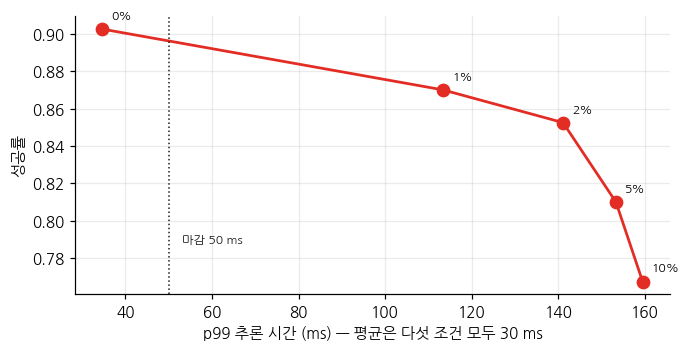

In [9]:
fig, ax = plt.subplots(figsize=(6.4, 3.3))
p99 = [np.percentile(res[p][2], 99) for p in PS]
okv = [res[p][0].mean() for p in PS]
ax.plot(p99, okv, "o-", color=RED, ms=8, lw=1.8)
for x, y, p in zip(p99, okv, PS):
    ax.annotate(f"{p * 100:.0f}%", (x, y), fontsize=8,
                xytext=(6, 6), textcoords="offset points")
ax.axvline(PERIOD_MS, color=INK, lw=1, ls=":")
ax.text(PERIOD_MS + 3, min(okv) + .02, "마감 50 ms",
        fontsize=8, color=INK)
ax.set_xlabel("p99 추론 시간 (ms) — 평균은 다섯 조건 모두 30 ms")
ax.set_ylabel("성공률")
plt.tight_layout()
plt.show()

## 마감은 모델만의 문제가 아니다

같은 모델이라도 제어 주기를 올리면 마감이 조여진다. 30 밀리초 평균은 20 Hz에서는 여유롭고 40 Hz에서는 아슬아슬하다.

튀는 비율을 2%로 고정한 채 제어 주기만 바꿔 본다.

In [10]:
def rollout_hz(net, sampler, hz, seed, n=200, reps=2):
    global CTRL_HZ, PERIOD_MS
    old_hz, old_ms = CTRL_HZ, PERIOD_MS
    CTRL_HZ, PERIOD_MS = hz, 1000. / hz
    try:
        torch.manual_seed(999)
        env = Vec(n, seed=seed)
        env.sub = int(round(1 / hz / MODEL.opt.timestep))
        rng = np.random.default_rng(seed + 7)
        held = np.zeros((n, 2))
        wait = np.zeros(n, int)
        miss, total, sc = 0, 0, []
        steps = int(EP * reps * hz / 20)
        for t in range(steps):
            fresh = wait <= 0
            if fresh.any():
                o = torch.from_numpy(env.obs())
                with torch.no_grad():
                    a = net.dist(o).sample().numpy()
                held[fresh] = a[fresh]
                hold = np.ceil(sampler(rng, n) / PERIOD_MS)
                wait[fresh] = hold.astype(int)[fresh]
                miss += int((hold[fresh] > 1).sum())
                total += int(fresh.sum())
            wait -= 1
            sc += env.step(held)[2]
        return (np.mean(sc) if sc else float("nan"), miss / total)
    finally:
        CTRL_HZ, PERIOD_MS = old_hz, old_ms

In [11]:
print(pad("제어 주기", 12) + pad("마감", 10, True)
      + pad("마감 놓침", 12, True))
for hz in (10, 20, 40):
    _, mr = rollout_hz(POLICY, SAMP[.02], hz, seed=11, reps=1)
    print(pad(f"{hz} Hz", 12)
          + pad(f"{1000. / hz:.0f} ms", 10, True)
          + pad(f"{mr * 100:.1f}%", 12, True))

제어 주기         마감   마감 놓침


10 Hz           100 ms        2.1%


20 Hz            50 ms        2.2%


40 Hz            25 ms       91.7%


## 정리

**로봇 추론에는 마감이 있고, 마감은 평균이 아니라 꼬리가 넘긴다.** 다섯 조건의 평균은 전부 30 밀리초였고 p99는 32에서 172까지 갈렸다. 성공률도 같이 갈렸다.

**늦은 명령은 없는 명령이 아니라 낡은 명령이다.** 마감을 놓치면 구동기가 지난 명령을 계속 내고, 그것이 로봇의 실제 거동을 바꾼다.

**마감은 모델과 제어 주기가 함께 정한다.** 같은 분포가 10 Hz에서는 여유롭고 40 Hz에서는 초과다. 「이 모델은 30 밀리초」는 절반의 정보이고, 나머지 절반은 제어 주기에 있다.

다음 노트북은 그 30 밀리초가 **어디서 오는지** 나눠 본다. 모델이 전부가 아니다.